### **GPT-2 (124M) in PyTorch notebook**
For raw code there'll be a train_gpt2.py file

In [1]:
from dataclasses import dataclass
import torch
from torch import nn, optim
from torch.nn import functional as F
import math

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # q, k, v for all heads
        self.c_attn = nn.Linear(config.n_embd, config.n_embd * 3)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        # Set a special flag for residual init
        self.c_proj.NANOGPT_SCALE_INIT = 1
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                             .view(1, 1, config.block_size, config.block_size))
    
    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=-1)
        """
        Why transpose like that? Because this way pytorch treats B and nh as batch dims
        And performs ops in parallel for these batches. This is exactly what we need - 
        run self-attention for multiple heads in parallel
        """
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # (B, nh, T, hs)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v  # (B, NH, T, T) @ (B, NH, T, HS) -> (B, NH, T, HS)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

**It's basically identical to attention from previous guide. The only reason for it to be this nasty is simlply efficiency of compute usage.**

In [4]:
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate="tanh")
        self.c_proj = nn.Linear(config.n_embd * 4, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
    
    def forward(self, x):
        return self.c_proj(self.gelu(self.c_fc(x)))

In [5]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)
    
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [6]:
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50_257
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

In [7]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # Weight Sharing Scheme
        self.transformer.wte.weight = self.lm_head.weight

        # Init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, "NANOGPT_SCALE_INIT"):
                # Special Scaling used in ChatGPT 2 res layers
                # To prevent std from explosion
                std *= (2 * self.config.n_layer)  ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, target=None):
        B, T = idx.size()
        assert T <= self.config.block_size
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        pos_emb = self.transformer.wpe(pos)
        tok_emb = self.transformer.wte(idx)
        x = tok_emb + pos_emb
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)
        loss = None
        if target is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), target.view(B*T))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [8]:
# Sampling from the model.

num_return_seq = 2
max_length = 100

model = GPT.from_pretrained("gpt2")
model.eval()
model.to(device)

c:\Users\rayga\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading weights from pretrained gpt: gpt2


GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [9]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

124439808

In [10]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long)  # (8,)
tokens = tokens.unsqueeze(0).repeat(num_return_seq, 1)  # (5, 8)
x = tokens.to(device)

In [11]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

while x.size(1) < max_length:
    with torch.inference_mode():
        logits, _ = model(x)  # (B, T, C)
        logits = logits[:, -1, :]  # (B, C)
        probs = F.softmax(logits, dim=-1)  # (B, C)
        topk_probs, topk_idcs = torch.topk(probs, 50, dim=-1)
        next_token = torch.multinomial(topk_probs, 1)  # (B,)
        next_token = torch.gather(topk_idcs, -1, next_token)
        x = torch.cat((x, next_token), dim=1)

In [12]:
for i in range(num_return_seq):
    tokens = x[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded, len(decoded))

> Hello, I'm a language model, not a program.

So this morning I started studying for the interview in the lab. This was not a hard question, I decided to do it before I knew what I was doing. The goal is this: I wanted to see if my results would be better than the results of other interviewers at the interview.

After some careful study of the question and the results of that study, I found that there is a lot of variation in this 433
> Hello, I'm a language model, and one of the main things that bothers me when they create languages is how easy it becomes to create something that is difficult to understand. I find myself more confused about how to understand than I normally am. And because of that, I try to work in a very informal way, which is not to say that I don't make mistakes. Sometimes people come up with new language features, and while I may not want to reinvent myself, it's fine to try 468


**This is a GPT-2 with loaded weights (not bad)**

Now, let's
### **Train it from scratch**

In [13]:
def sample(model, prompt, max_length=30, num_return_seq=5):
    tokens = enc.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long)  # (8,)
    tokens = tokens.unsqueeze(0).repeat(num_return_seq, 1)  # (5, 8)
    x = tokens.to(device)
    while x.size(1) < max_length:
        with torch.inference_mode():
            logits, _ = model(x)  # (B, T, C)
            logits = logits[:, -1, :]  # (B, C)
            probs = F.softmax(logits, dim=-1)  # (B, C)
            topk_probs, topk_idcs = torch.topk(probs, 50, dim=-1)
            next_token = torch.multinomial(topk_probs, 1)  # (B,)
            next_token = torch.gather(topk_idcs, -1, next_token)
            x = torch.cat((x, next_token), dim=1)
    for i in range(num_return_seq):
        tokens = x[i, :max_length].tolist()
        decoded = enc.decode(tokens)
        print(">", decoded, len(decoded))

In [14]:
# random init
model = GPT(GPTConfig()).to(device)

In [15]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
sample(model, "Hi everyone!")

> Hi everyone!�innon 71 Pilgrim Pilgrim studies pending�Champationally limitlessDAQ hopletionimens rendition anticipateevery Anyonebeard Dive clout cloutComplOakCombat unaccount 175
> Hi everyone! clust commands Starr 423 muscle discharged Anyone craensiveensiveessen semifinals semifinals Meansoppinghetical Ent FurthermoreBWjac Schedule giveaway calculated beginning pressures efficiency luckily 213
> Hi everyone! Salad Railroad lineup bombersling makes══מ Rutgersparse shifted Furthermore qualify thighsimmigration Having syRevolutionDN troublesome negatives ingestionInstead revolver 71 arousDN 195
> Hi everyone!Combat version repayment troublesome troublesome Dragonbound Furthermore egregiousbrowserrival spill MOR rail'''' againup protests MORBW swords SR applications worsAdv 109 ho Harlem 193
> Hi everyone! topical --> 191 Request leadingussiaittee quasiland warp RequestTem Hirosh'''' 1903lam pseudo religious captured kidn owningandr buzzing177 census 56 reviewed 171


In [16]:
with open("input.txt", "r") as f:
    text = f.read()
data = text[:1_000]
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [17]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [18]:
# Batches of text (B*T) -> (B, T)
buf = torch.tensor(tokens[:24+1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [19]:
# ----------------------------------
# mini dataloader

B, T = 4, 32
buf = torch.tensor(tokens[:B*T + 1]).to(device)
x = buf[:-1].view(B, T)
y = buf[1:].view(B, T)

model = GPT(GPTConfig())
model.to(device)
logits, loss = model(x, y)

print(logits.shape)
print(loss)

torch.Size([4, 32, 50257])
tensor(11.0088, device='cuda:0', grad_fn=<NllLossBackward0>)


From the loss, which is $-\ln(1/50257)=10,82$ - not too far from our loss

In [20]:
# Optimization.

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
for i in range(50):
    optimizer.zero_grad()
    logits, loss = model(x, y)  # Overfitting single batch
    loss.backward()
    optimizer.step()
    if i % 10 == 0:
        print(f"Step {i} Loss: {loss.item()}")

Step 0 Loss: 11.008784294128418
Step 10 Loss: 6.794595718383789
Step 20 Loss: 3.8946571350097656
Step 30 Loss: 1.9155133962631226
Step 40 Loss: 0.6221328973770142


In [21]:
# It overfitted it!
sample(model, "First Citizen", num_return_seq=2)

> First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
 97
> First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
 97


In [22]:
"""
DataLoaderLite
"""
class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T

        with open("input.txt", "r") as f:
            text = f.read()
        enc = tiktoken.get_encoding("gpt2")
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches")

        self.cur_pos = 0

    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.cur_pos:self.cur_pos+B*T+1]
        x = buf[:-1].view(B, T)
        y = buf[1:].view(B, T)
        self.cur_pos += B*T

        # When next batch exceeds dataset size
        # Loop it to the beginning
        if self.cur_pos + (B*T + 1) > len(self.tokens):
            self.cur_pos = 0
        return x, y

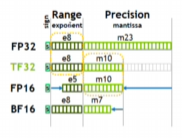

In [23]:
from tqdm import tqdm

In [30]:
torch.cuda.empty_cache()

In [ ]:
B, T = 4, 1024
dataloader = DataLoaderLite(B, T)

# Precision optimization (more efficiency) - default highest
# highest: FP32, high: TF32
torch.set_float32_matmul_precision("high")
# Optimization.
model = GPT(GPTConfig()).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
for i in tqdm(range(1_000)):
    optimizer.zero_grad()
    xb, yb = dataloader.next_batch()
    xb, yb = xb.to(device), yb.to(device)
    # Mixed precision
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        # It changes precision of logits and stuff
        # Not of parameters
        logits, loss = model(xb, yb)
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Step {i} Loss: {loss.item()}")

loaded 338024 tokens
1 epoch = 82 batches


  0%|          | 0/1000 [00:07<?, ?it/s]


TritonMissing: Cannot find a working triton installation. Either the package is not installed or it is too old. More information on installing Triton can be found at: https://github.com/triton-lang/triton

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"


In [28]:
sample(model, "First Citizen", num_return_seq=1, max_length=128)

> First Citizen:
The Duke'd his world to, it.
COMay our friends; upon the earth, if they have my royal more men, thou lie: but not; for not made him,

My tongue for us:
The Lords of his great thousandness,

FirstEO:

QARENCE:
That we heard to it is I'll think you have in all

Secondest it may say, if this lord



HAR RENESTER:
KING RICHARDO,
Why, yet, thy mother; to see him:
That with us 388
